In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib.animation import FuncAnimation, PillowWriter

## Histograms

By partitioning the data into bins (intervals) and showing the frequency of data points that fall within each bin, a histogram shows how a numerical data is distributed. They are useful in data analysis to identify patterns or anomalies in the distribution.

From Wikipedia

> "A histogram is a visual representation of the distribution of quantitative data. The term was first introduced by Karl Pearson. To construct a histogram, the first step is to "bin" (or "bucket") the range of values— divide the entire range of values into a series of intervals—and then count how many values fall into each interval. The bins are usually specified as consecutive, non-overlapping intervals of a variable. The bins (intervals) are adjacent and are typically (but not required to be) of equal size."

> "Histograms give a rough sense of the density of the underlying distribution of the data, and often for density estimation: estimating the probability density function of the underlying variable."

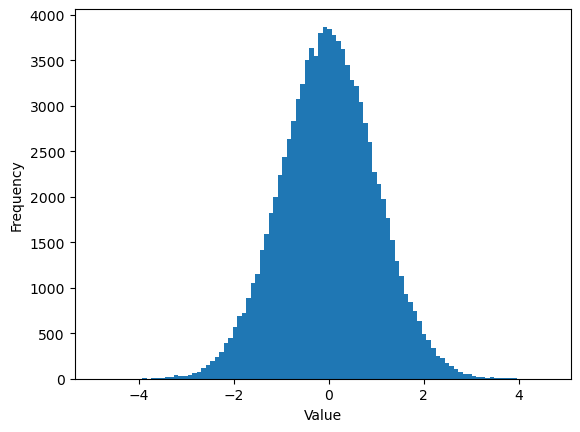

In [2]:
# Creating Histograms with Matplotlib

# random data
data = np.random.randn(100000)
data.std()

# histogram
plt.hist(data, bins=100)
plt.xlabel("Value")
plt.ylabel("Frequency");

22 85


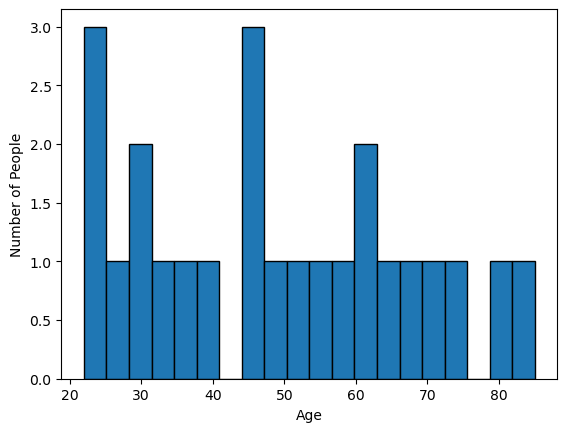

In [3]:
# Another example: ages of people in a survey
ages = np.array([22, 23, 25, 27, 29, 30, 32, 35, 40, 45, 46, 47, 50, 52, 55, 57, 60, 61, 65, 68, 70, 75, 80, 85])

len(ages)
print(ages.min(), ages.max())

plt.hist(ages, bins=20, edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Number of People")
pass;

In [4]:
# check seaborn too, it's very useful for data analysis and plots.

## Playing with random numbers

[0, 0, 0, 1, 1, 0, 0, 1, 0, 1]
4 6 0.4 0.6


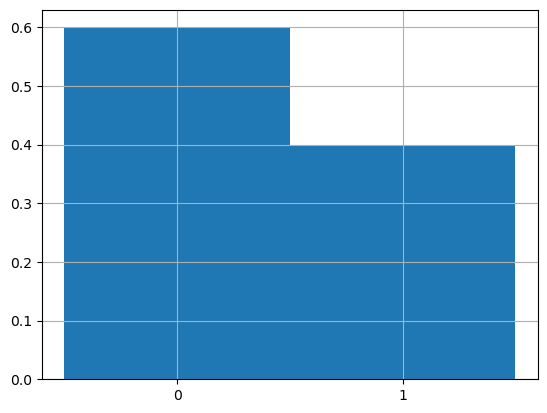

In [16]:
import random

# random.choice(["A", 1, 1.2])

def coin_toss():
    return random.choice([1, 0])


# coin_toss()
# Simulate N coin tosses
# for _ in range(10):
#     coin_toss()

N = 10  # increase the number of tosses. what do you expect to happen?
tosses = [coin_toss() for _ in range(N)]  # list comprehension
print(tosses)
count_H = 0
count_T = 0
for toss in tosses:
    if toss == 1:
        count_H = count_H + 1
    else:
        count_T = count_T + 1
print(count_H, count_T, count_H / len(tosses), count_T / len(tosses))
plt.hist(tosses, bins=[-0.5, 0.5, 1.5], density=True)
plt.xticks([0, 1])
plt.grid();

Counter({np.int64(1): 492, np.int64(0): 263, np.int64(2): 245})


<BarContainer object of 3 artists>

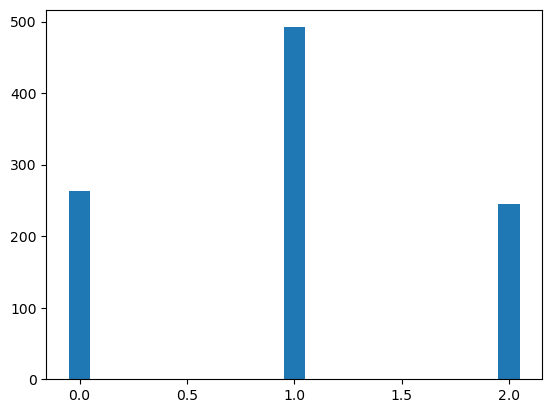

In [6]:
# Counting heads in two coin tosses. label 'H' by 1 and 'T' by 0. Is the result expected? what do you need to make it closer to expected?
trials = 1000
for i in range(1, trials + 1):
    # print(f"Number of trials = {i}")
    count = 0
    sum = []
    for j in range(1, i + 1):
        # draw randomly from {0,1}, TWICE
        random_array = np.random.binomial(1, 0.5, size=2)
        sum_i = np.sum(random_array)
        # print(f"Outcome {j} = {random_array} and number of heads = {sum_i}")
        sum.append(sum_i)
# print(sum)
# Counter([1,2,2,3,4])
print(Counter(sum))
plt.bar(Counter(sum).keys(), Counter(sum).values(), width=0.1)
# pass;

In [7]:
print(np.random.choice(["H", "T"]))

H


Step chosen: [[-1 -1  1 ...  1  1 -1]
 [-1  1  1 ... -1 -1 -1]
 [-1 -1 -1 ... -1  1  1]
 ...
 [ 1  1  1 ... -1 -1  1]
 [ 1 -1 -1 ...  1  1  1]
 [-1 -1  1 ...  1  1 -1]]
Position at each time step: [[ -1  -2  -1 ...   8   9   8]
 [ -1   0   1 ... -10 -11 -12]
 [ -1  -2  -3 ... -26 -25 -24]
 ...
 [  1   2   3 ...  -6  -7  -6]
 [  1   0  -1 ... -14 -13 -12]
 [ -1  -2  -1 ... -50 -49 -50]]


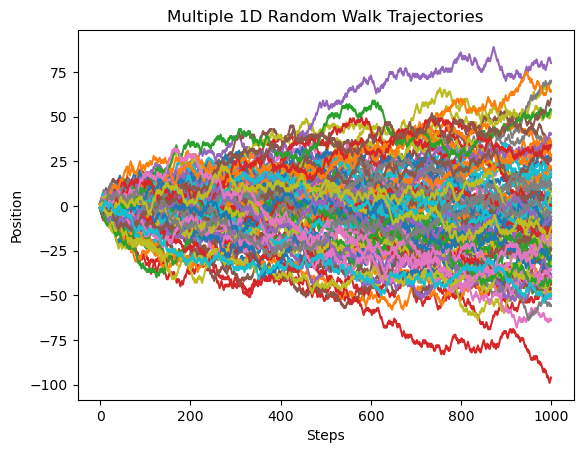

In [15]:
n_steps = 1000
n_walks = 100

# generate random steps of -1 or 1 for each walk

# documentation: https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html
# IMPORTANT: Always look up documentation! Other than 'how to use it', it often points to the method's limitation (and sometimes provide suggestions for other relevant tools.) For example, why you shouldn't use numpy random module if you care about security or cryptography: https://numpy.org/doc/stable/reference/random/index.html

steps = np.random.choice([-1, 1], size=(n_walks, n_steps))
print(f"Step chosen: {steps}")
# compute cumulative sum along each row to get final positions. Notice that the final element in each row is the final position.
walks = np.cumsum(steps, axis=1)
print(f"Position at each time step: {walks}")

for i in range(n_walks):
    plt.plot(walks[i], label=f"Walk {i+1}")

plt.title("Multiple 1D Random Walk Trajectories")
plt.xlabel("Steps")
plt.ylabel("Position")
pass;
# plt.legend();

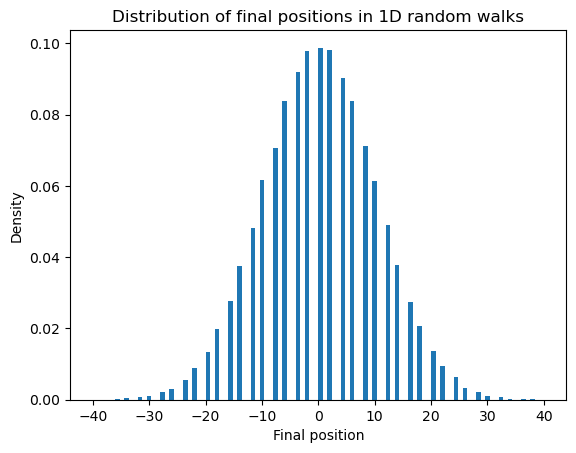

In [17]:
# Number of steps and number of walks
n_steps = 100
n_walks = 100000

steps = np.random.choice([-1, 1], size=(n_walks, n_steps))
walks = np.cumsum(steps, axis=1)
# print(walks)
# as I mentioned, the last element is the final position in each step
final_positions = walks[:, -1]
# print(final_positions)

# Plot the distribution of final positions. Remember: it's the histogram of final positions that has a normal distribution.

plt.hist(final_positions, bins=100, density=True)
plt.title("Distribution of final positions in 1D random walks")
plt.xlabel("Final position")
plt.ylabel("Density")
pass;

## Linear regression: minimal example

Slope ($m$) = 1.90
Intercept ($c$) = 0.50
y(x=2.3) = 4.87


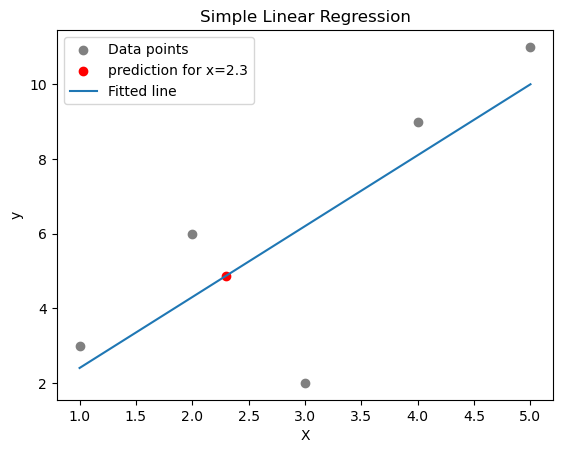

In [41]:
from sklearn.linear_model import LinearRegression


X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1) # makes X a column vector
y = np.array([3, 6, 2, 9, 11])

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope ($m$) = {slope:.2f}") # print first two decimals
print(f"Intercept ($c$) = {intercept:.2f}")

# check your fitted line for a `new` point. this is why we were fitting a linear regression in the first place: to know y-value for new x-values.
x_test = 2.3
X_new = np.array([[x_test]])
y_pred = model.predict(X_new)

print(f"y(x={x_test}) = {y_pred[0]:.2f}")

plt.scatter(X, y, label="Data points",color='gray')
plt.scatter(x_test,y_pred[0],color='red',label=f'prediction for x={x_test}')
plt.plot(X, model.predict(X), label="Fitted line")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Simple Linear Regression")
plt.legend()
pass;